# Regression Preprocessing

This notebook prepares the common regression dataset for predicting flow_duration. It includes feature selection, target analysis, feature engineering, train/test split, and preprocessing setup while preventing data leakage. All regression models will use the same preprocessed data and test set.

## Load Data

We load the cleaned dataset from the common cleaning stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/RT_IOT2022_cleaned.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (117922, 83)

First few rows:


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [2]:
print("Column names:")
print(df.columns.tolist())

Column names:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fw

In [3]:
print("Data types:")
print(df.dtypes)

Data types:
id.orig_p                 int64
id.resp_p                 int64
proto                    object
service                  object
flow_duration           float64
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type              object
Length: 83, dtype: object


## Identify Target

The regression target is flow_duration. We analyze its distribution and properties.

In [4]:
target = "flow_duration"

print(f"Target: {target}")
print(f"Data type: {df[target].dtype}")
print(f"Missing values: {df[target].isnull().sum()}")

Target: flow_duration
Data type: float64
Missing values: 0


In [5]:
print("Target statistics:")
print(df[target].describe())

Target statistics:
count    117922.000000
mean          3.808474
std         127.064242
min           0.000000
25%           0.000001
50%           0.000004
75%           0.000005
max       21728.335578
Name: flow_duration, dtype: float64


In [6]:
print(f"Skewness: {df[target].skew():.2f}")

Skewness: 128.39


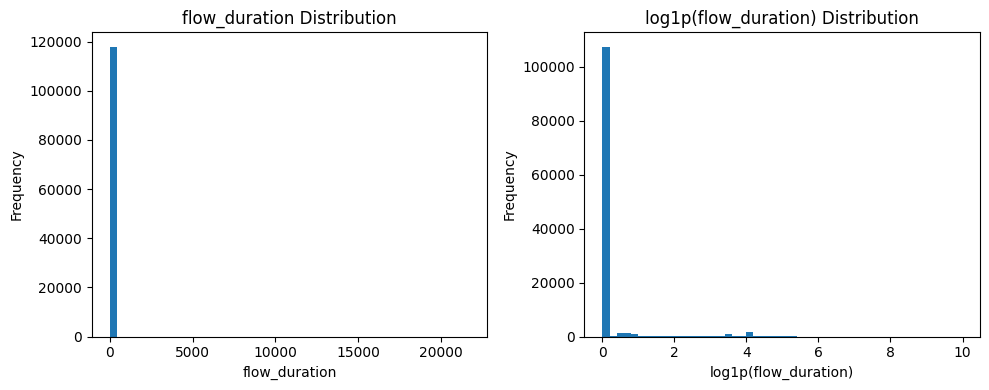

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df[target], bins=50)
plt.xlabel('flow_duration')
plt.ylabel('Frequency')
plt.title('flow_duration Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df[target]), bins=50)
plt.xlabel('log1p(flow_duration)')
plt.ylabel('Frequency')
plt.title('log1p(flow_duration) Distribution')

plt.tight_layout()
plt.show()

The target is highly right-skewed. A log1p transformation may help with model performance. If we use log1p for training, we will convert predictions back to the original scale for final evaluation using expm1.

## Selecting Features for Regression

We inspect the available columns and remove features that would leak the target or are inappropriate for regression.

In [8]:
print("All columns:")
print(df.columns.tolist())

All columns:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fwd

### Remove Target-Leakage Features

The following features are removed because they directly contain or are mathematically derived from flow_duration:

**Timing/Inter-arrival features (flow_iat.*, fwd_iat.*, bwd_iat.*):**
These are inter-arrival times calculated from packet timestamps. Since flow_duration is the total duration of the flow, inter-arrival statistics are directly derived from the same timing information and would leak the target.

**Active statistics (active.*):**
These measure active time periods within the flow. They are directly derived from the flow duration and would leak the target.

**Idle statistics (idle.*):**
These measure idle time periods within the flow. They are directly derived from the flow duration and would leak the target.

**Rate-based features (fwd_pkts_per_sec, bwd_pkts_per_sec, flow_pkts_per_sec, payload_bytes_per_second):**
Rates are calculated as counts divided by flow_duration. Using these would give the model the target in the denominator, making the regression task artificially easy.

**Classification target (Attack_type):**
This is the classification target and is not a predictor for regression.

In [9]:
# Identify columns to drop
drop_cols = []

# Timing/inter-arrival features
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)

# Active statistics
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)

# Idle statistics
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)

# Rate-based features
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)

# Classification target
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

print(f"Columns to drop ({len(drop_cols)}):")
print(drop_cols)

Columns to drop (30):
['fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fwd_iat.std', 'bwd_iat.min', 'bwd_iat.max', 'bwd_iat.tot', 'bwd_iat.avg', 'bwd_iat.std', 'flow_iat.min', 'flow_iat.max', 'flow_iat.tot', 'flow_iat.avg', 'flow_iat.std', 'active.min', 'active.max', 'active.tot', 'active.avg', 'active.std', 'idle.min', 'idle.max', 'idle.tot', 'idle.avg', 'idle.std', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second', 'Attack_type']


In [10]:
df_reg = df.drop(columns=drop_cols)
print(f"Features before selection: {len(df.columns)}")
print(f"Features after selection: {len(df_reg.columns)}")
print(f"Columns removed: {len(drop_cols)}")

Features before selection: 83
Features after selection: 53
Columns removed: 30


In [11]:
print("Remaining features:")
print(df_reg.columns.tolist())

Remaining features:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_subflow_pkts', 'bwd_subflow_pkts', 'fwd_subflow_bytes', 'bwd_subflow_bytes', 'fwd_bulk_bytes', 'bwd_bulk_bytes', 

## Categorical Features

We identify categorical columns that will need encoding.

In [12]:
cat_cols = df_reg.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features: {cat_cols}")

Categorical features: ['proto', 'service']


In [13]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df_reg[col].value_counts())


proto:
proto
tcp     105592
udp      12296
icmp        34
Name: count, dtype: int64

service:
service
-         98199
dns        9444
mqtt       4132
http       3289
ssl        2656
ntp         115
dhcp         29
irc          28
ssh          28
radius        2
Name: count, dtype: int64


## Feature Engineering

We create meaningful features from the existing data without leaking the target.

### Total Packets

**What it represents:** The total number of packets in the flow (forward + backward).

**Why it is meaningful:** Network flow duration is often correlated with the total number of packets exchanged. Flows with more packets typically take longer to complete.

**Why it may help predict flow_duration:** Total packet count is a fundamental characteristic of network traffic that directly relates to how long a flow takes to complete, without directly encoding the duration itself.

**Why it does not leak the target:** This is a simple sum of packet counts, which are independent measurements of the flow. It does not contain timing information or flow_duration in its calculation.

In [14]:
# Verify the columns exist
if 'fwd_pkts_tot' in(df_reg.columns) and 'bwd_pkts_tot' in df_reg.columns:
    df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']
    print("Created feature: total_packets")
else:
    print("Required columns for total_packets not found")

Created feature: total_packets


## Outlier Handling

We inspect the target and key numerical features for outliers. Network traffic naturally contains extreme flows, especially attack traffic.

In [15]:
print("Target outlier check:")
q1 = df_reg[target].quantile(0.25)
q3 = df_reg[target].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df_reg[(df_reg[target] < lower) | (df_reg[target] > upper)]
print(f"IQR range: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_reg)*100:.2f}%)")

Target outlier check:
IQR range: [-0.00, 0.00]
Outliers: 18783 (15.93%)


## Regression-Specific EDA

We perform exploratory data analysis focused on the regression task of predicting flow_duration.

### Feature Distributions

We examine the distributions of key numerical features to understand their characteristics.

In [ ]:
# Select key numerical features for distribution analysis
key_numeric_features = ['fwd_pkts_tot', 'bwd_pkts_tot', 'total_packets', 'fwd_header_size_tot', 'bwd_header_size_tot', 'down_up_ratio']

plt.figure(figsize=(15, 10))
for i, col in enumerate(key_numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_reg[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** The feature distributions show similar extreme right-skewness as the target. Most flows have very small packet counts and header sizes, with a small number of flows having extremely large values. This skewness is typical for network traffic data and supports the decision to preserve outliers rather than removing them.

### Correlation Heatmap

We examine correlations between numerical features to identify multicollinearity and relationships with the target.

In [ ]:
# Compute correlation matrix for numerical features (including target)
numeric_cols_for_corr = df_reg.select_dtypes(include=[np.number]).columns.tolist()
# Limit to first 20 features for readability
subset_corr_cols = numeric_cols_for_corr[:20]
corr_matrix = df_reg[subset_corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Subset of Numerical Features)")
plt.tight_layout()
plt.show()

**Observation:** The correlation heatmap shows several clusters of highly correlated features. For example, forward packet counts (fwd_pkts_tot) are strongly correlated with forward data packets and header sizes. This indicates multicollinearity in the dataset, which tree-based models will handle well but may affect linear models. The engineered feature total_packets shows expected high correlation with its component features (fwd_pkts_tot and bwd_pkts_tot).

### Feature-Target Relationships

We examine scatter plots between key features and the target to understand their relationships.

In [ ]:
plt.figure(figsize=(14, 6))

# Scatter Plot 1: Total Packets vs flow_duration
plt.subplot(1, 2, 1)
plt.scatter(df_reg['total_packets'], df_reg[target], alpha=0.5, s=1)
plt.xlabel('Total Packets')
plt.ylabel('flow_duration')
plt.title('Total Packets vs flow_duration')
plt.xscale('log')
plt.yscale('log')

# Scatter Plot 2: fwd_header_size_tot vs flow_duration
plt.subplot(1, 2, 2)
plt.scatter(df_reg['fwd_header_size_tot'], df_reg[target], alpha=0.5, s=1)
plt.xlabel('Forward Header Size Total')
plt.ylabel('flow_duration')
plt.title('Forward Header Size vs flow_duration')
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()

**Observation:** The scatter plots show a positive relationship between packet counts/header sizes and flow_duration on the log-log scale. As total packets or header size increases, flow_duration also tends to increase. However, the relationship is not linear and shows considerable variance, which suggests that simple linear models may not capture the full complexity of the relationship. The log scale helps visualize patterns that would be obscured by the extreme skewness of the data.

The outlier percentage is expected for network traffic data. Extreme values may represent legitimate attack observations or long-lived flows. We preserve these observations rather than removing them, as they contain valuable information about network behavior.

## Train/Test Split

We create a single train/test split that will be used by all regression models. This ensures fair comparison across models.

In [16]:
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Training proportion: {len(X_train)/len(df_reg)*100:.1f}%")

Training samples: 94337
Testing samples: 23585
Training proportion: 80.0%


## Preprocessing Without Data Leakage

We set up preprocessing that will be fitted only on training data. Different models have different preprocessing requirements:

- **Linear models (Linear, Ridge, Lasso, ElasticNet, SVR, KNN):** Require feature scaling
- **Tree-based models (Decision Tree, Random Forest, Gradient Boosting):** Do not require scaling

Categorical encoding will also be done without leakage using sklearn Pipelines in the model notebooks.

In [17]:
# Identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(num_cols)}):")
print(num_cols)
print(f"\nCategorical features ({len(cat_cols)}):")
print(cat_cols)

Numerical features (51):
['id.orig_p', 'id.resp_p', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_subflow_pkts', 'bwd_subflow_pkts', 'fwd_subflow_bytes', 'bwd_subflow_bytes', 'fwd_bulk_bytes', 'bwd_bulk_bytes', 'fwd_bulk_packets', 'bwd_bulk_pa

## Save Split Indices for Reproducibility

We save the train/test indices to ensure both regression members use the exact same split.

In [18]:
train_indices = X_train.index.tolist()
test_indices = X_test.index.tolist()

np.savez(
    "regression_split_indices.npz",
    train_indices=train_indices,
    test_indices=test_indices
)
print("Split indices saved to: regression_split_indices.npz")

Split indices saved to: regression_split_indices.npz


In [19]:
# Verify the saved file
loaded = np.load("regression_split_indices.npz")
print(f"Loaded train indices: {len(loaded['train_indices'])}")
print(f"Loaded test indices: {len(loaded['test_indices'])}")

Loaded train indices: 94337
Loaded test indices: 23585


## Final Verification

We verify the preprocessing state before proceeding to model training.

In [20]:
print("=== Regression Preprocessing Summary ===")
print(f"\nOriginal cleaned dataset shape: {df.shape}")
print(f"Final regression feature count: {len(X_train.columns)}")
print(f"\nTarget: {target}")
print(f"\nCategorical features: {cat_cols}")
print(f"Numerical features: {len(num_cols)}")
print(f"\nEngineered features: ['total_packets']")
print(f"\nRemoved leakage/identifier features ({len(drop_cols)}):")
for col in drop_cols:
    print(f"  - {col}")

=== Regression Preprocessing Summary ===

Original cleaned dataset shape: (117922, 83)
Final regression feature count: 53

Target: flow_duration

Categorical features: ['proto', 'service']
Numerical features: 51

Engineered features: ['total_packets']

Removed leakage/identifier features (30):
  - fwd_iat.min
  - fwd_iat.max
  - fwd_iat.tot
  - fwd_iat.avg
  - fwd_iat.std
  - bwd_iat.min
  - bwd_iat.max
  - bwd_iat.tot
  - bwd_iat.avg
  - bwd_iat.std
  - flow_iat.min
  - flow_iat.max
  - flow_iat.tot
  - flow_iat.avg
  - flow_iat.std
  - active.min
  - active.max
  - active.tot
  - active.avg
  - active.std
  - idle.min
  - idle.max
  - idle.tot
  - idle.avg
  - idle.std
  - fwd_pkts_per_sec
  - bwd_pkts_per_sec
  - flow_pkts_per_sec
  - payload_bytes_per_second
  - Attack_type


In [21]:
print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")


Training rows: 94337
Testing rows: 23585


In [22]:
print("\n=== Verification Checks ===")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")
print(f"Missing values in y_test: {y_test.isnull().sum()}")


=== Verification Checks ===
Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [23]:
print(f"\nTarget not in X_train: {target not in X_train.columns}")
print(f"Target not in X_test: {target not in X_test.columns}")


Target not in X_train: True
Target not in X_test: True


In [24]:
print(f"\nTrain size correct: {abs(len(X_train)/len(df_reg) - 0.8) < 0.01}")
print(f"Test size correct: {abs(len(X_test)/len(df_reg) - 0.2) < 0.01}")


Train size correct: True
Test size correct: True


In [25]:
print(f"\nCategorical columns identified correctly: {set(cat_cols) == set(df_reg.select_dtypes(include=['object']).columns)}")


Categorical columns identified correctly: True


The preprocessing is complete. The regression datasets are ready for model training. All models will use the same train/test split and feature definitions.